# Understanding Saliency Maps in Deep Learning
This Jupyter Notebook discusses how neural networks interpret images using gradient-based attribution methods

The notebook will cover the following:

- Input gradients (vanilla saliency)
- Guided backpropogation
- SmoothGrad
- How noise and gradients affect interpretability

The goal of this notebook is not just to show the implementation of these methods but to understand *why these methods behave the way they do*.

In [1]:
## The following Python packages will be used throughout this Jupyter Notebook
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

## Step 1: Loading a Pretrained Model

For this project, ResNet18 that is trained on ImageNet will be used as the pretrained model for this project. This model allows the ability to see how
a real deep learning model "sees" images.

In [2]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Step 2: Image Preprocessing

The images that are going to be used in the model must be resized and converted into tensors before being passed into the network.

In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

def preprocess(image):
    return transform(image).unsqueeze(0)

## Step 3: Input Image

A sample image will be used to observe how gradients highlight important regions.

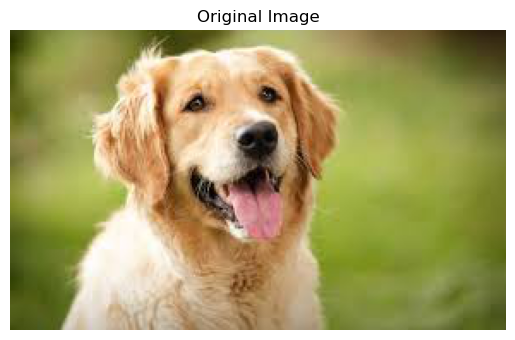

In [4]:
image = Image.open("dog.jpg").convert("RGB")
input_tensor = preprocess(image)

plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

## Step 4: Vanilla Saliency (Input Gradients)

We compute the gradients of the output with respect to the input image. This will inform us which pixels most influence the prediction

In [5]:
def vanilla_saliency(input_tensor):
    input_tensor = input_tensor.clone().detach().requires_grad_(True)

    model.zero_grad()
    output = model(input_tensor)
    score = output.max()

    score.backward()

    saliency = input_tensor.grad.abs().squeeze().numpy()
    saliency = np.max(saliency, axis=0)

    return saliency

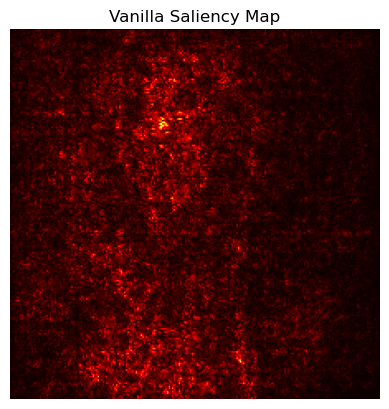

In [6]:
saliency = vanilla_saliency(input_tensor)

plt.imshow(saliency, cmap="hot")
plt.title("Vanilla Saliency Map")
plt.axis("off")
plt.show()

## Observation
Through this, we can observe that vanilla saliency maps are often noisy, unstable and hard to predict. When small changes are made to the input,
the gradients that are calculated can drastically change

## Step 5: SmoothGrad

The SmoothGrad technique is used to improve saliency by adding noise multiple times and averaging results.

This reduces visual noise and highlights consistent features.

In [7]:
def smoothgrad(input_tensor, n_samples=20, noise_level=0.1):
    total_grad = torch.zeros_like(input_tensor)

    for _ in range(n_samples):
        noise = torch.randn_like(input_tensor) * noise_level
        noisy_input = (input_tensor + noise).detach().requires_grad_(True)

        model.zero_grad()
        output = model(noisy_input)
        score = output.max()
        score.backward()

        total_grad += noisy_input.grad.abs()

    saliency = total_grad / n_samples
    saliency = saliency.squeeze().numpy()
    saliency = np.max(saliency, axis=0)

    return saliency

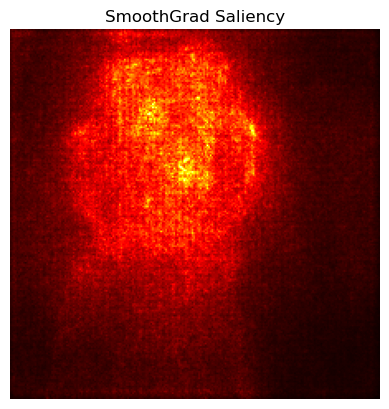

In [8]:
smooth = smoothgrad(input_tensor, n_samples=30, noise_level=0.2)

plt.imshow(smooth, cmap="hot")
plt.title("SmoothGrad Saliency")
plt.axis("off")
plt.show()

## Step 6: Effects of Noise Level

Testing was performed using different noise levels to see how noise affects the results of the SmoothGrad method

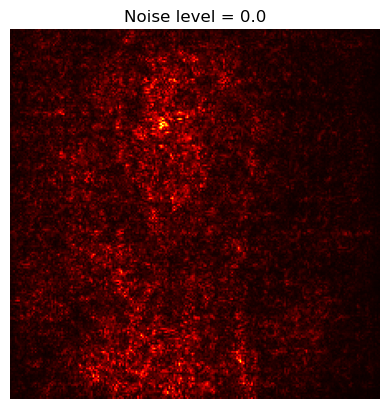

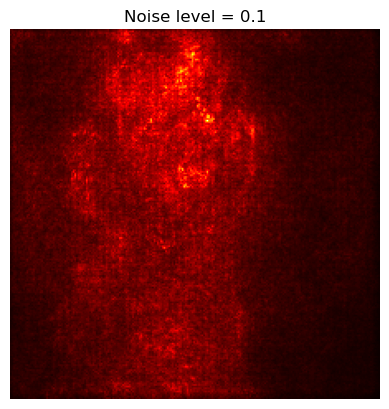

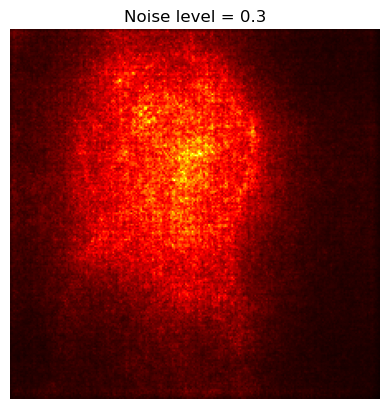

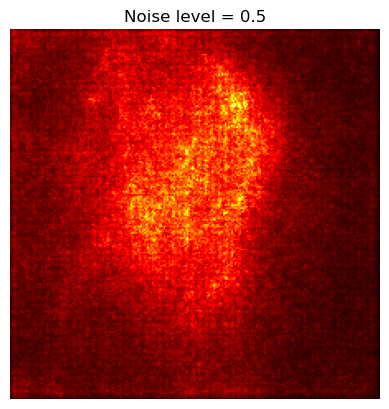

In [9]:
for noise in [0.0, 0.1, 0.3, 0.5]:
    result = smoothgrad(input_tensor, n_samples=20, noise_level=noise)

    plt.figure()
    plt.imshow(result, cmap="hot")
    plt.title(f"Noise level = {noise}")
    plt.axis("off")
    plt.show()

## Key Insight

Through this, we can deduce the following:

- The Vanilla saliency approach is sensitive but noisy
- The SmoothGrad approach is stable and interpretable
- Noise acts as a “smoothing filter” over gradients

This shows that interpretability methods are highly dependent on design choices.

## Real World Applications

Saliency Maps can be used in:

- medical imaging (tumour detection explanations)
- autonomous driving systems
- debugging deep learning models
- bias detection in datasets